['horse-or-human']
['validation-horse-or-human']
(1027, 128, 128, 3)
(1027,)
(256, 128, 128, 3)
(256,)


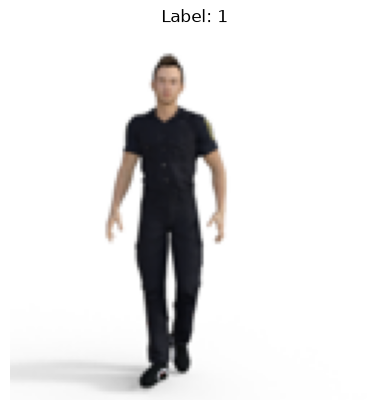

(1027, 128, 128, 3)
(49152, 1027)
(49152, 256)
(1, 1027)
[[ 0.87935784 -1.84279222  0.84824756 ...  1.61044957  1.90599729
  -1.42280335]]


In [10]:
from re import X

import numpy as np
import matplotlib.pyplot as plt
%run "01_data_preparation.ipynb"

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [12]:
def initialize_parameters(n_x):
    w = np.zeros((n_x,1))
    b = 0.0

    return w,b


In [22]:
def forward_propagation(X,w,b):
    z = np.dot(w.T,X)  + b
    A = sigmoid(z)

    return A


In [23]:
def cost_function(X,Y,A):
    m = X.shape[1]
    A_safe = np.clip(A, 1e-12, 1 - 1e-12)
    loss = np.sum(Y * np.log(A_safe) + (1 - Y) * np.log(1 - A_safe))
    cost = -(1/m) * loss
    return cost


In [24]:
def backward_propagation(A, Y,X):
    m = X.shape[1]
    dZ = A -  Y
    dw = (1/m ) * (np.dot(X,dZ.T))
    db = (1/ m) * np.sum(dZ)
    #remember dw and w shape should be the sam
    grads = {"dw": dw, "db": db}
    # print("X shape: ", X.shape)
    # print("Y shape: ", Y.shape)
    # print("A shape: ", A.shape)
    # print("dZ shape: ", dZ.shape)
    # print("dw shape: ", dw.shape)
    # print("w shape: ", w.shape)
    # print("db shape: ", db.shape)
    # print("b shape", b.shape)

    return grads


In [25]:
batch_size = 32
X_batch = X_train_shuffled[:, :batch_size]
Y_batch = y_train_shuffled[:, :batch_size]

n_x = X_batch.shape[0]
w, b = initialize_parameters(n_x)
#
# A = forward_propagation(X_batch, w, b)
# cost = cost_function(X_batch, Y_batch, A)
# grads = backward_propagation(A, Y_batch, X_batch)


In [26]:
import copy
def optimization(w,b, X, Y,num_epochs= 1000,batch_size=32,lr=0.001):
    costs = []
    rng = np.random.default_rng(42)
    m = X.shape[1]
    for _ in range(num_epochs):
        permutation = rng.permutation(m)
        X = X[:, permutation]
        Y = Y[:, permutation]
        for start in range(0,m,batch_size):
            end = start + batch_size
            X_batch = X[:, start:end]
            Y_batch = Y[:, start:end]

            A = forward_propagation(X_batch, w, b)
            cost = cost_function(X_batch, Y_batch, A)
            grads = backward_propagation(A, Y_batch, X_batch)
            w -= lr * grads["dw"]
            b -= lr * grads["db"]
            costs.append(cost)
    params = {"w": w, "b": b}
    grads = {"dw": grads["dw"], "db": grads["db"]}

    return params, grads, costs





In [27]:
def prediction(w, b, X):
    A = forward_propagation(X, w, b)
    y_pred = (A >= 0.5).astype(int)
    return y_pred

In [52]:
w, b = initialize_parameters(n_x)
params,grads, costs = optimization(w, b, X_train_normalized, y_train, num_epochs= 5,batch_size=32,lr=0.001)

In [66]:
m = X_train_normalized.shape[1]
batch_size = 32

batch_sizes = np.array([
    min(batch_size, m - start)
    for start in range(0, m, batch_size)
])

number_of_batches = len(batch_sizes)
number_of_epochs = len(costs) // number_of_batches

batch_costs = np.array(costs).reshape(
       number_of_epochs,
    number_of_batches
)

epoch_costs = np.average(
    batch_costs,
    axis=1,
    weights=batch_sizes
)

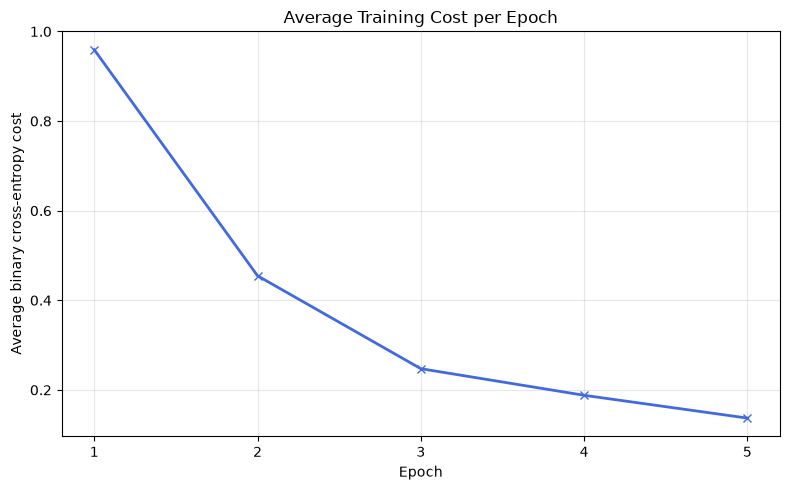

In [68]:
epochs = np.arange(1, number_of_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    epoch_costs,
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.xlabel("Epoch")
plt.ylabel("Average binary cross-entropy cost")
plt.title("Average Training Cost per Epoch")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
training_w = params["w"]
training_b = params["b"]



training_prediction = prediction(training_w, training_b, X_train_normalized)
validation_prediction = prediction(training_w, training_b, X_validation_normalized)


training_accuracy = np.mean(training_prediction == y_train) * 100
validation_accuracy = np.mean(validation_prediction  == y_validation) * 100
print("Training Accuracy:", training_accuracy)
print("-" * 45)
print("Validation Accuracy:" , validation_accuracy)





Training Accuracy: 96.20253164556962
---------------------------------------------
Validation Accuracy: 77.734375


## Experiment results

| Epochs | Batch size | Learning rate | Training accuracy | Validation accuracy |
|---:|---:|---:|---:|---:|
| **5** | 32 | 0.001 | 96.20% | **77.73%** |
| 10 | 32 | 0.001 | 98.93% | 74.61% |
| 25 | 32 | 0.001 | 100.00% | 67.97% |
| 50 | 32 | 0.001 | 100.00% | 69.53% |
| 500 | 32 | 0.001 | 100.00% | 68.75% |

**Best tested model:** 5 epochs, with 77.73% validation accuracy.

In [62]:
horse_mask = y_validation == 0
human_mask = y_validation == 1

In [63]:
horse_accuracy = np.mean(validation_prediction[horse_mask] == 0) * 100
human_accuracy = np.mean(validation_prediction[human_mask] == 1) * 100
print("Horse accuracy:", horse_accuracy)
print("Human accuracy:", human_accuracy)

Horse accuracy: 63.28125
Human accuracy: 92.1875


In [64]:
misclassified_horse_indices = np.where(
    (y_validation[0] == 0)
    & (validation_prediction[0] == 1)
)[0]

print("Misclassified horses:", len(misclassified_horse_indices))

Misclassified horses: 47


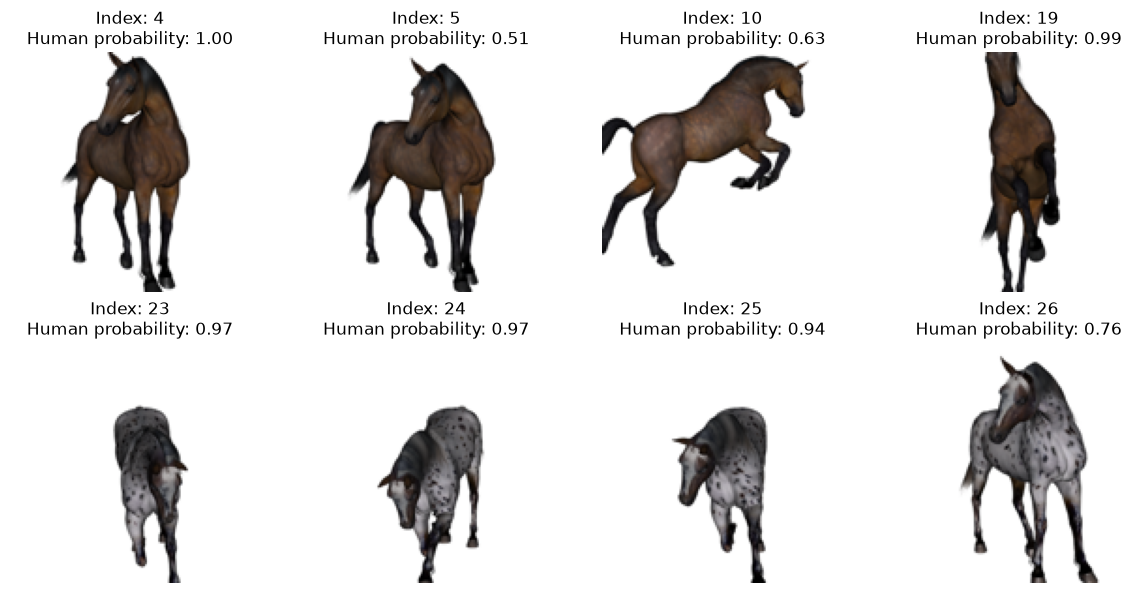

In [65]:
validation_probabilities = forward_propagation(
    X_validation_normalized,
    training_w,
    training_b
)

number_to_show = 8

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for position, ax in enumerate(axes.flat):
    if position < min(number_to_show, len(misclassified_horse_indices)):
        index = misclassified_horse_indices[position]

        ax.imshow(validation_images[index])
        ax.set_title(
            f"Index: {index}\n"
            f"Human probability: "
            f"{validation_probabilities[0, index]:.2f}"
        )
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()